# Task 3 Energy Consumption Time Series Forecasting

## Objective: 

Energy Consumption Time Series Forecasting.

## Introduction

Energy consumption forecasting is essential for efficient energy management and planning. Accurate predictions help utility providers optimize electricity distribution, reduce operational costs, and manage peak demand effectively.

In this project, time-series forecasting techniques are applied to predict short-term household energy usage based on historical consumption patterns.

## Problem Statement

The objective of this project is to forecast short-term household energy consumption using historical time-based data.

Different models including ARIMA, Prophet, and XGBoost will be applied and compared to determine which method provides the most accurate predictions.

The performance of each model will be evaluated using MAE and RMSE metrics.

## Dataset Description

The dataset used is the Household Power Consumption dataset, which contains time-series data of electric power usage.

Key features include:

- Date and Time: Timestamp of measurement  
- Global Active Power: Household energy consumption (kilowatts)  
- Voltage: Voltage level  
- Sub_metering: Energy usage in different areas  

The dataset requires preprocessing such as datetime parsing and resampling to make it suitable for time-series analysis.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

## Load Dataset

In [2]:
df = pd.read_csv("data.csv", sep=';', low_memory=False)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


## Data Cleaning and Parsing

In [3]:
# Combine Date and Time
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

# Set index
df.set_index('datetime', inplace=True)

# Convert to numeric
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

# Drop missing values
df = df[['Global_active_power']].dropna()

## Resampling Time Series

In [4]:
# Resample to hourly data
df_hourly = df.resample('h').mean()

df_hourly.head()

,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


## Feature Engineering

In [5]:
df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek
df_hourly['month'] = df_hourly.index.month

## Train Test Split

In [6]:
train = df_hourly[:'2010-01-01']
test = df_hourly['2010-01-02':]

## ARIMA Model

In [7]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train['Global_active_power'], order=(5,1,0))
model_arima_fit = model_arima.fit()

pred_arima = model_arima_fit.forecast(steps=len(test))

## Prophet Model

In [8]:
!pip install prophet

In [9]:
from prophet import Prophet

# Prepare data
prophet_df = df_hourly.reset_index()
prophet_df = prophet_df[['datetime', 'Global_active_power']]
prophet_df.columns = ['ds', 'y']

model_prophet = Prophet()
model_prophet.fit(prophet_df)

future = model_prophet.make_future_dataframe(periods=len(test), freq='h')
forecast = model_prophet.predict(future)

pred_prophet = forecast['yhat'][-len(test):].values

22:15:15 - cmdstanpy - INFO - Chain [1] start processing
22:16:02 - cmdstanpy - INFO - Chain [1] done processing


# XGBoost Model

In [10]:
!pip install xgboost

In [11]:
from xgboost import XGBRegressor

features = ['hour', 'dayofweek', 'month']

X_train = train[features]
y_train = train['Global_active_power']

X_test = test[features]
y_test = test['Global_active_power']
# Drop any rows where the target or features are missing
train = train.dropna(subset=['Global_active_power'] + features)
test = test.dropna(subset=['Global_active_power'] + features)

# Re-assign your X and y after dropping NaNs
X_train = train[features]
y_train = train['Global_active_power']
X_test = test[features]
y_test = test['Global_active_power']
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

## Evaluation Metrics

In [19]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_final(y_true, y_pred):
    # Flatten and convert to numpy
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Force lengths to match the shortest one
    min_len = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:min_len], y_pred[:min_len]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# Print results for all models
print("ARIMA:  ", evaluate_final(test['Global_active_power'], pred_arima))
print("Prophet:", evaluate_final(test['Global_active_power'], pred_prophet))
print("XGBoost:", evaluate_final(y_test, pred_xgb))

ARIMA:   (0.6612415968719966, np.float64(0.9457496357229419))
Prophet: (0.7474373636651453, np.float64(0.9397796988024341))
XGBoost: (0.4583082670907431, np.float64(0.6352174644699714))


## Visualization

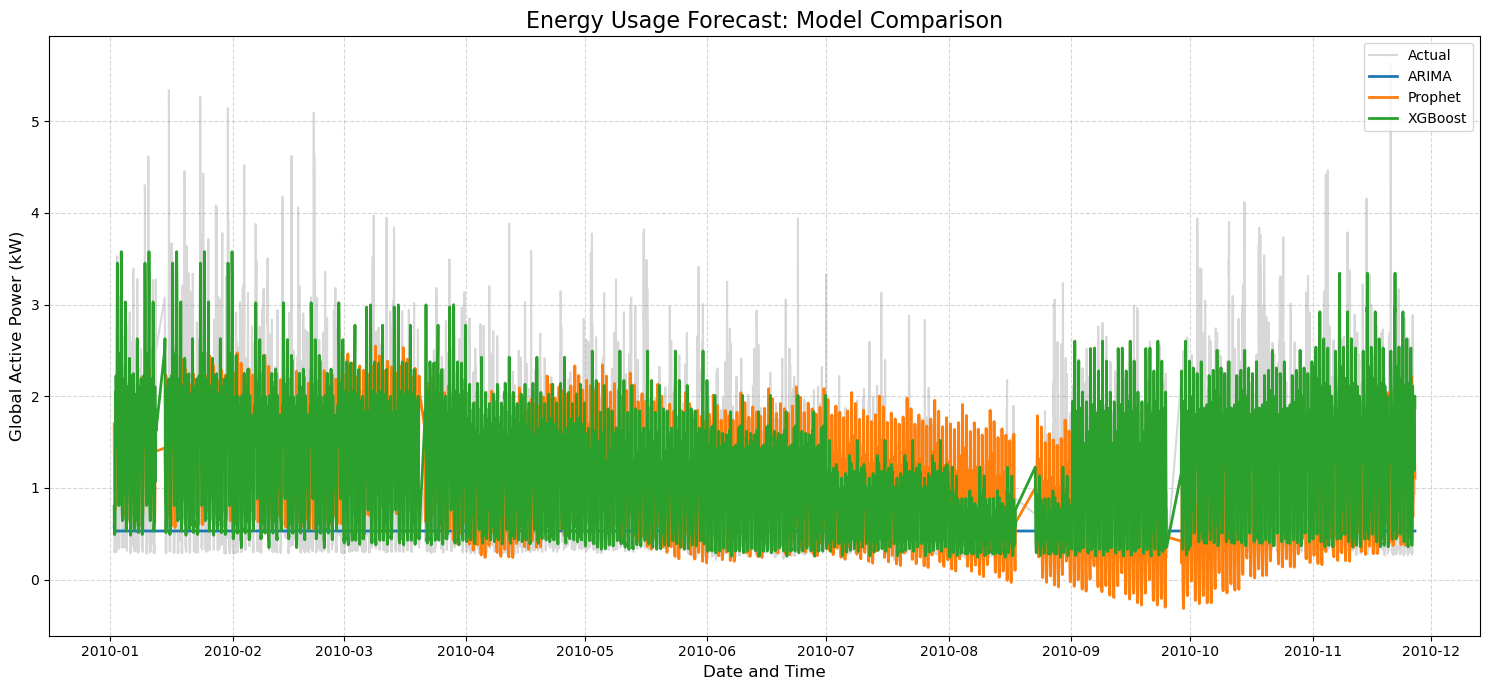

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# 1. Plot Actual Data
plt.plot(test.index, test['Global_active_power'], label='Actual', alpha=0.3, color='gray')

# 2. Plot ARIMA (Slicing the prediction to match the index length)
plt.plot(test.index, pred_arima[:len(test.index)], label='ARIMA', linewidth=2)

# 3. Plot Prophet
plt.plot(test.index, pred_prophet[:len(test.index)], label='Prophet', linewidth=2)

# 4. Plot XGBoost
plt.plot(test.index, pred_xgb[:len(test.index)], label='XGBoost', linewidth=2)

# Chart Formatting
plt.title("Energy Usage Forecast: Model Comparison", fontsize=16)
plt.xlabel("Date and Time", fontsize=12)
plt.ylabel("Global Active Power (kW)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Model Insights

- ARIMA provided a good baseline for short-term forecasting.

- Prophet effectively captured seasonality and trends in the data.

- XGBoost performed well when time-based features were included.

- Feature engineering significantly improved machine learning model performance.

- Model comparison showed differences in handling temporal patterns.

## Business Insights

- Energy consumption shows strong daily and weekly patterns.
- Peak usage hours can be identified and managed efficiently.
- Forecasting helps utility companies optimize supply and reduce costs.
- Data-driven predictions improve energy planning and resource allocation.

## Conclusion

This project demonstrates how time-series forecasting techniques can be applied to predict energy consumption. By comparing ARIMA, Prophet, and XGBoost models, valuable insights were gained into model performance and temporal patterns.

The results highlight the importance of feature engineering and model selection in time-series analy